# Stock prices

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import requests
from datetime import datetime, timedelta

In [2]:
API_KEY = "Ga1fx1Xsm16JnrzyIk_C_ImKlNzCtRKz"

In [3]:
def fix_datetime_on_dataframe(df):
    df['date'] = pd.to_datetime(df['t'], origin='unix', unit='ms')
    return df.set_index(keys='date').drop(columns='t')

In [4]:
def fix_column_names_on_dataframe(df):
    mapping = {
        'o': 'open',
        'c': 'close',
        'h': 'high',
        'l': 'low',
        'n': 'number',
        'v': 'volume',
        'vw': 'avg_price'
    }
    return df.rename(columns=mapping)

In [5]:
def create_stock_df_of_company(company_code):
    company_code = company_code.upper()

    start_date = datetime.today() - timedelta(days=91)
    end_date = datetime.today() - timedelta(days=1)
    start = datetime.strftime(start_date, "%Y-%m-%d")
    end = datetime.strftime(end_date, "%Y-%m-%d")

    url = f"https://api.massive.com/v2/aggs/ticker/{company_code}/range/1/day/{start}/{end}?apiKey={API_KEY}"

    api_data = requests.get(url).json()

    df = pd.DataFrame(api_data['results'])

    df = fix_datetime_on_dataframe(df)
    df = fix_column_names_on_dataframe(df)
    df['company_code'] = company_code
    return df

In [6]:
apple_df = create_stock_df_of_company('AAPL')
apple_df.head()

,volume,avg_price,open,close,high,low,number,company_code
date,,,,,,,,
2026-01-23 05:00:00,41688982.0,247.5598,247.32,248.04,249.410,244.68,629226,AAPL
2026-01-26 05:00:00,55969234.0,254.6109,251.48,255.41,256.560,249.80,771970,AAPL
2026-01-27 05:00:00,49648271.0,259.6602,259.17,258.27,261.950,258.21,698663,AAPL
2026-01-28 05:00:00,41287971.0,256.2135,257.65,256.44,258.855,254.51,620112,AAPL
2026-01-29 05:00:00,67253009.0,258.2492,258.00,258.28,259.650,254.41,923855,AAPL


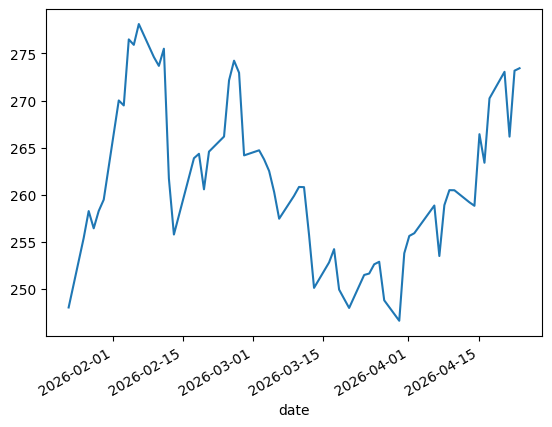

In [7]:
apple_df['close'].plot(kind='line');

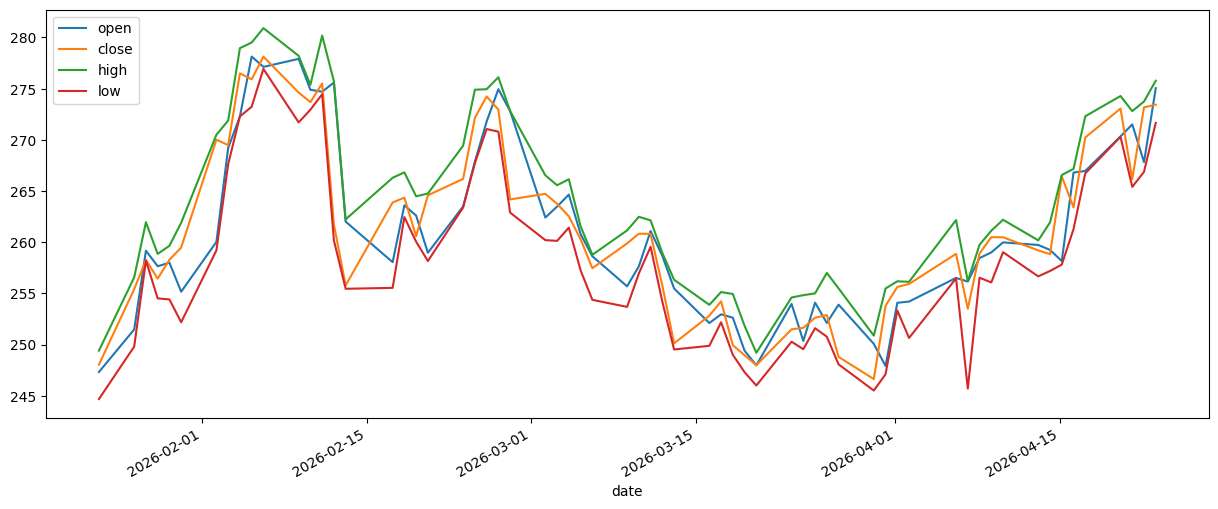

In [15]:
apple_df[['open', 'close', 'high', 'low']].plot(kind='line', figsize=(15,6));

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('apple',
    index_name=apple_df.index.name,
    index_type=apple_df.index.dtype,
    columns=apple_df.columns
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.10.6, pytest-7.1.3, pluggy-1.0.0 -- /Users/jules/.pyenv/versions/3.10.6/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /Users/jules/code/lewagon/data-solutions/02-Data-Toolkit/02-Data-Sourcing/01-Stock-Market-API/tests
plugins: asyncio-0.19.0, anyio-3.6.2
asyncio: mode=strict
collecting ... collected 3 items

test_apple.py::TestApple::test_apple_df_columns PASSED                   [ 33%]
test_apple.py::TestApple::test_apple_df_index_is_timestamp PASSED        [ 66%]
test_apple.py::TestApple::test_apple_df_index_name_is_date PASSED        [100%]

============================== 3 passed in 0.34s ===============================


💯 You can commit your code:

git add tests/apple.pickle

git commit -m 'Completed apple step'

git push origin master



In [16]:
# Set default figsize for all notebook (usefull in TS analysis)
matplotlib.rcParams['figure.figsize'] = (15, 6)

In [17]:
codes = ['AMZN', 'GOOGL', 'META']
stock_dfs = [apple_df]
for code in codes:
    stock_dfs.append(create_stock_df_of_company(code))

In [18]:
stocks_df = pd.concat(stock_dfs)
stocks_df.head()

,volume,avg_price,open,close,high,low,number,company_code
date,,,,,,,,
2026-01-23 05:00:00,41688982.0,247.5598,247.32,248.04,249.410,244.68,629226,AAPL
2026-01-26 05:00:00,55969234.0,254.6109,251.48,255.41,256.560,249.80,771970,AAPL
2026-01-27 05:00:00,49648271.0,259.6602,259.17,258.27,261.950,258.21,698663,AAPL
2026-01-28 05:00:00,41287971.0,256.2135,257.65,256.44,258.855,254.51,620112,AAPL
2026-01-29 05:00:00,67253009.0,258.2492,258.00,258.28,259.650,254.41,923855,AAPL


<Axes: xlabel='date'>

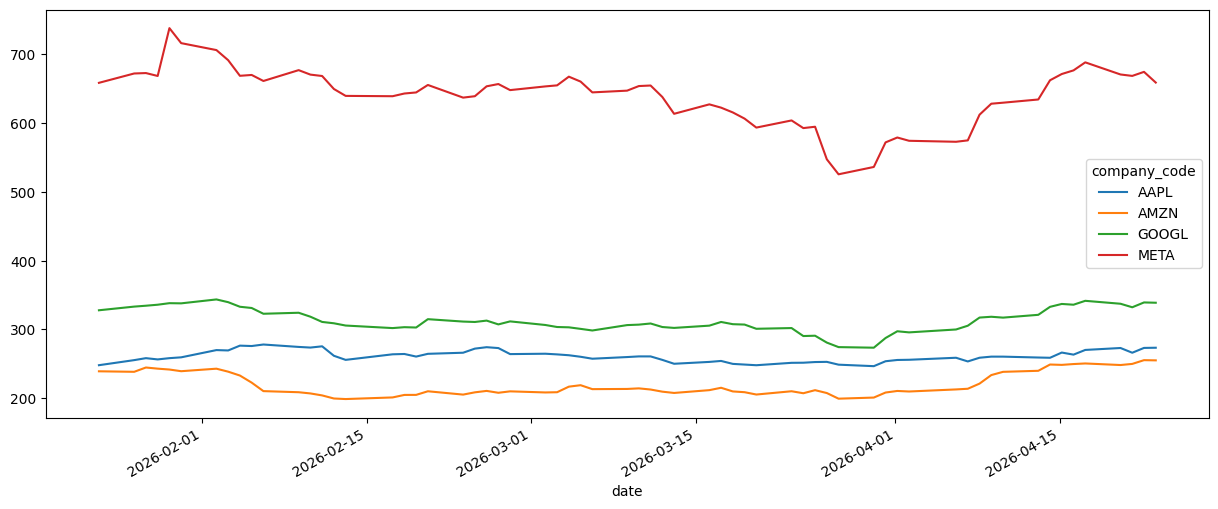

In [19]:
# Pivot the table to get company_code as columns
pivot_df = stocks_df.pivot(columns='company_code', values='close')
pivot_df.plot(kind='line')

In [13]:
def normalize(series):
    return series / series[0]

normalized_pivot = pivot_df.apply(normalize, axis=0)

/var/folders/32/7brgkn013hjc1zlbmg4kpvfw0000gn/T/ipykernel_39544/1697112155.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return series / series[0]


<Axes: xlabel='date'>

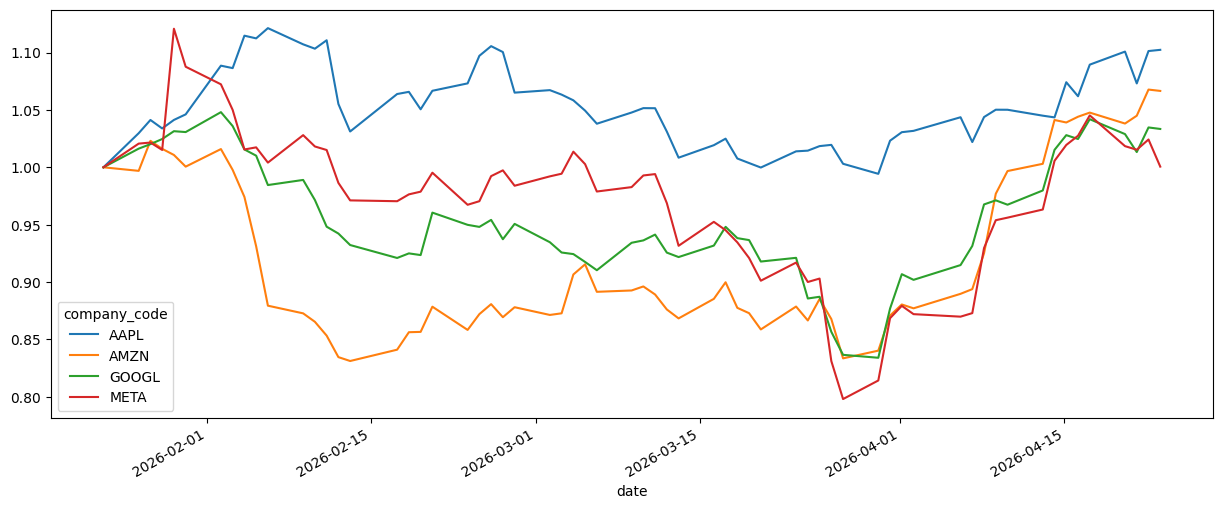

In [20]:
normalized_pivot.plot(kind='line')